#1. Algorithm Explanation

1-SVR stands for Support Vector Regression. It is a supervised machine learning algorithm used to predict continuous numerical values (like stock prices, house prices, or temperatures).

1-What is the algorithm? Support Vector Regression (SVR) is a machine learning algorithm used to predict continuous numerical values. Unlike traditional models that minimize total errors, SVR fits a "tolerance tube" around your data, allowing for a certain margin of error (epsilon) while prioritizing a flat, generalized line or curve

2-How does the algorithm work? predicts continuous values by finding a line or plane (hyperplane) that best fits the data. Unlike traditional regression that minimizes all errors, SVR ignores errors within a certain acceptable distance and focuses on fitting the closest critical data

3-When should this algorithm be used? Standard PCA breaks down when outliers are severe because square errors weight massive outliers heavily. SVT uses soft-thresholding on singular values, allowing it to mathematically "peel away" extreme outliers into a sparse error matrix while keeping the underlying structure intact.

4-Advantages and limitations for SVT algorthem

Memory & Storage Efficiency: Computes only the top singular values per iteration (via soft-thresholding) on sparse matrices, making it scale extremely well to massive low-rank datasets.
SIAM Publications Library Theoretical Guarantees: Solves a convex relaxation (nuclear norm minimization) that guarantees exact low-rank recovery without needing you to specify or guess the target rank in advance.
SIAM Publications Library Limitations: Slow on Dense/Noisy Data: Iterations become computationally heavy when data isn't sparse or when singular values decay slowly, leading to poor convergence rates compared to non-convex matrix factorization methods.

#2. Exploratory Data Analysis (EDA)

####Import Library

In [87]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)

In [88]:
df = pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86


In [89]:
print("Number of rows:", df.shape[0])
print("Number of Columns", df.shape[1])

Number of rows: 1338
Number of Columns 7


In [90]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   expenses  1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [91]:
df.describe()

,age,bmi,children,expenses
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.665471,1.094918,13270.422414
std,14.049960,6.098382,1.205493,12110.011240
min,18.000000,16.000000,0.000000,1121.870000
25%,27.000000,26.300000,0.000000,4740.287500
50%,39.000000,30.400000,1.000000,9382.030000
75%,51.000000,34.700000,2.000000,16639.915000
max,64.000000,53.100000,5.000000,63770.430000


In [92]:
print("Target Variable:", df.columns[-1])
print("Features:", df.columns[:6])

Target Variable: expenses
Features: Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region'], dtype='object')


In [93]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
expenses,0


##2.1 Univariate Analysis



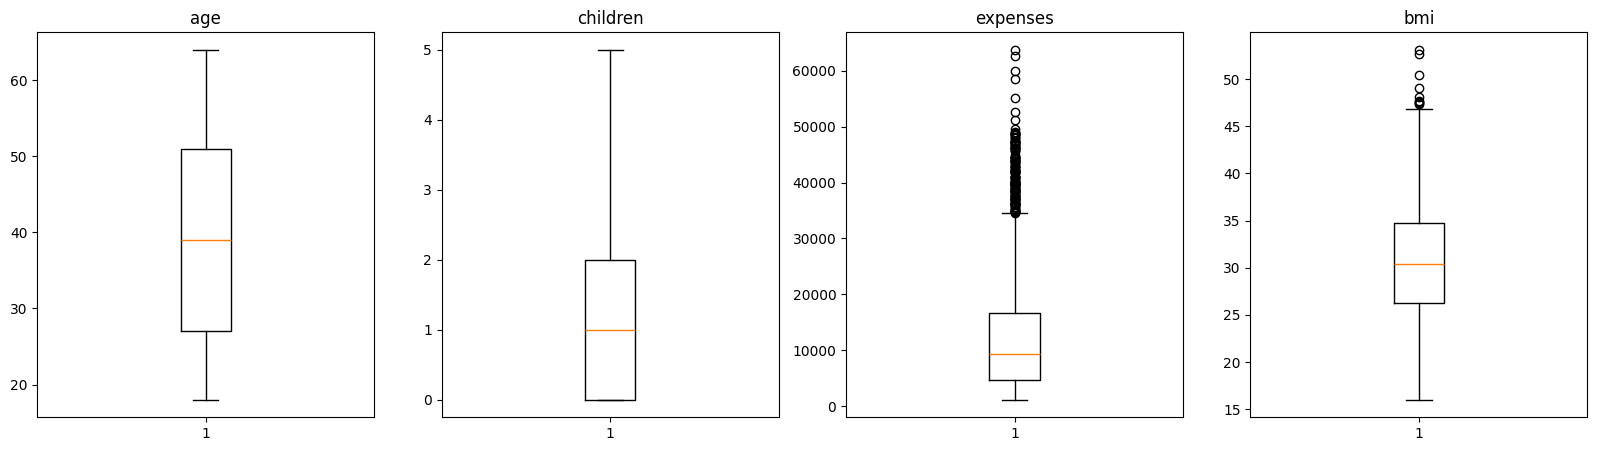

In [94]:
columns = [
    "age",
    "children",
    "expenses",
    "bmi"
]

n_cols = 4
n_rows = math.ceil(len(columns) / n_cols)

plt.figure(figsize=(5 * n_cols, 5 * n_rows))

for i, col in enumerate(columns, 1):
    plt.subplot(n_rows, n_cols, i)
    plt.boxplot(df[col].dropna())
    plt.title(col)

plt.show()

#####The box plots show the distribution of the numerical features and help identify outliers. The variables Age and Children do not contain significant outliers, while BMI has a few outliers. Expenses contains a large number of high-value outliers, indicating that some individuals have much higher medical expenses than the majority of the dataset.

##2.1 Bivariate Analysis

In [95]:
df.groupby("sex")["expenses"].mean()

,expenses
sex,
female,12569.578897
male,13956.751420


In [96]:
df.groupby("region")["expenses"].mean()

,expenses
region,
northeast,13406.384691
northwest,12417.575169
southeast,14735.411538
southwest,12346.937908


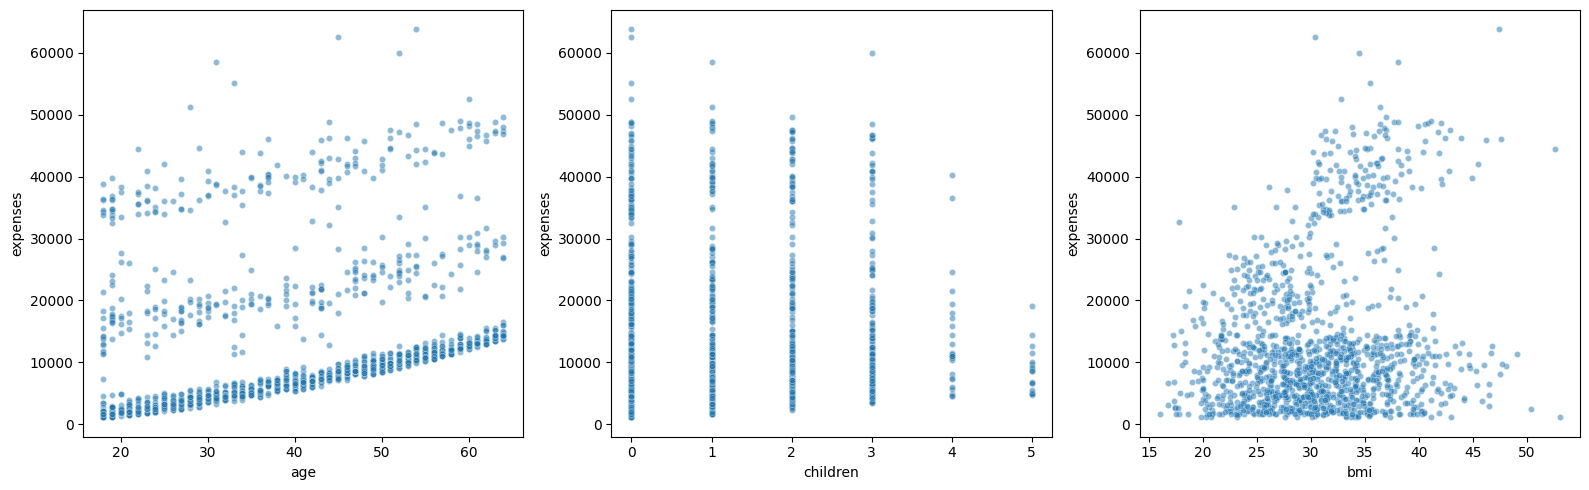

In [97]:
features = [
    "age",
    "children",
    "bmi"
]

n_cols = 3
n_rows = math.ceil(len(features) / n_cols)

plt.figure(figsize=(16, 5 * n_rows))

for i, feature in enumerate(features, 1):

    plt.subplot(n_rows, n_cols, i)

    sns.scatterplot(
        data=df,
        x=feature,
        y="expenses",
        alpha=0.5,
        s=20
    )

    plt.xlabel(feature)
    plt.ylabel("expenses")

plt.tight_layout()
plt.show()

##2.3 Multivariate

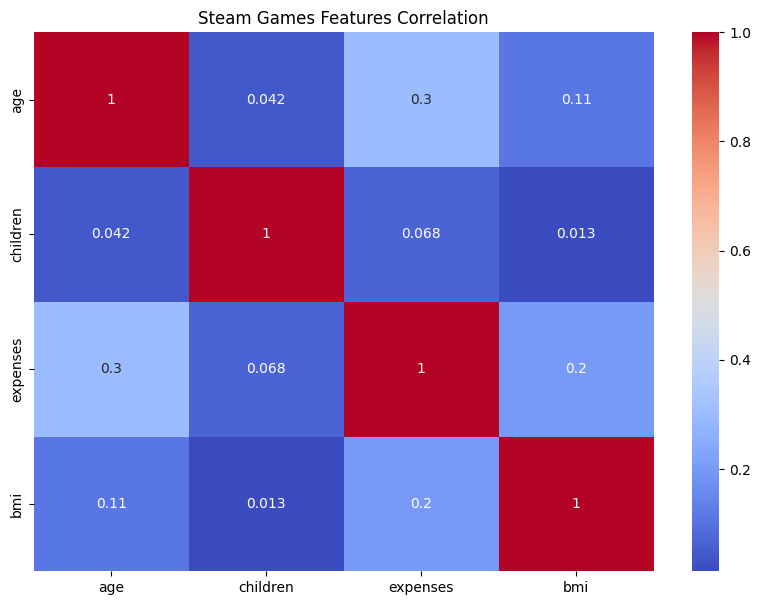

In [98]:
columns = [
    "age",
    "children",
    "expenses",
    "bmi"
]

corr = df[columns].corr()

plt.figure(figsize=(10,7))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Steam Games Features Correlation")
plt.show()

#3. Data Preprocessing

Checking for Null Values

In [99]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
expenses,0



The Dataset does not contains Null Values

Checking for Duplicates

In [100]:
df.duplicated().sum()

np.int64(1)

Drop duplicates

In [101]:
df.drop_duplicates(inplace = True)

In [102]:
df.duplicated().sum()

np.int64(0)

Encoding Categorical Variables

In [103]:
#Our Target Variable
y = df['expenses']

In [104]:
#Selected Features to train the model
x = df.drop("expenses", axis=1)

In [105]:
#Encoding Categorical variables (Sex, Smoker, Region)
x = pd.get_dummies(x,columns=["sex","smoker","region"],drop_first=True, dtype=int)

In [106]:
x

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.9,0,0,1,0,0,1
1,18,33.8,1,1,0,0,1,0
2,28,33.0,3,1,0,0,1,0
3,33,22.7,0,1,0,1,0,0
4,32,28.9,0,1,0,1,0,0
...,...,...,...,...,...,...,...,...
1333,50,31.0,3,1,0,1,0,0
1334,18,31.9,0,0,0,0,0,0
1335,18,36.9,0,0,0,0,1,0
1336,21,25.8,0,0,0,0,0,1


Feature Scaling

In [107]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


scaler_x = StandardScaler()
x_train_scaled = scaler_x.fit_transform(x_train)
x_test_scaled = scaler_x.transform(x_test)


A scaler is a tool that converts your data into a standard range so your model treats all features equally.

By using StandardScaler to transform features into a distribution with a mean of 0 and a standard deviation of 1, we ensure each feature contributes proportionally to the model's objective function. The process is divided into fit(), which calculates these statistical parameters strictly from the training set, and transform(), which applies them to the data; this separation is critical to maintain mathematical consistency and prevent data leakage, ensuring the model evaluates unseen data without being biased by the scale of different variables

In [108]:
x

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.9,0,0,1,0,0,1
1,18,33.8,1,1,0,0,1,0
2,28,33.0,3,1,0,0,1,0
3,33,22.7,0,1,0,1,0,0
4,32,28.9,0,1,0,1,0,0
...,...,...,...,...,...,...,...,...
1333,50,31.0,3,1,0,1,0,0
1334,18,31.9,0,0,0,0,0,0
1335,18,36.9,0,0,0,0,1,0
1336,21,25.8,0,0,0,0,0,1


#4. Model Implementation

In [124]:
model = SVR(kernel='rbf', C=2000, epsilon=8)
model.fit(x_train_scaled, y_train)

SVR(C=2000, epsilon=8)

In [125]:
model2 = SVR(kernel='rbf', C=50000, epsilon=1500)
model2.fit(x_train_scaled, y_train)

SVR(C=50000, epsilon=1500)

#5. Model Evaluation

## before improving hyperparameters

In [126]:
y_pred = model.predict(x_test_scaled)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("R-squared (R2) score for Training Set:", r2)
print("Root Mean Squared Error (RMSE) for Training Set:", rmse)
print("Mean Squared Error (MSE) for Training Set:", mse)

R-squared (R2) score for Training Set: 0.8064390982207164
Root Mean Squared Error (RMSE) for Training Set: 5963.8905360861445
Mean Squared Error (MSE) for Training Set: 35567990.32641788


## After improving

In [127]:
y_pred2 = model2.predict(x_test_scaled)

mse_2 = mean_squared_error(y_test, y_pred2)
rmse_2 = np.sqrt(mse_2)
r2_2 = r2_score(y_test, y_pred2)

print("R-squared (R2) score for Training Set:", r2_2)
print("Root Mean Squared Error (RMSE) for Training Set:", rmse_2)
print("Mean Squared Error (MSE) for Training Set:", mse_2)

R-squared (R2) score for Training Set: 0.8840312900330013
Root Mean Squared Error (RMSE) for Training Set: 4616.27059569059
Mean Squared Error (MSE) for Training Set: 21309954.21263756


# **Bouns**

## implement another model

In [120]:
linear_model = LinearRegression()
linear_model.fit(x_train_scaled, y_train)

LinearRegression()

## evaluate it

In [121]:
ly_pred = linear_model.predict(x_test_scaled)
ly_test_original = y_test.values.reshape(-1, 1)

l_mse = mean_squared_error(y_test, ly_pred)
l_rmse = np.sqrt(l_mse)
l_r2 = r2_score(y_test, ly_pred)

print("R-squared (R2) score for Training Set:", l_r2)
print("Root Mean Squared Error (RMSE) for Training Set:", l_rmse)
print("Mean Squared Error (MSE) for Training Set:", l_mse)

R-squared (R2) score for Training Set: 0.8069099329048421
Root Mean Squared Error (RMSE) for Training Set: 5956.632571843689
Mean Squared Error (MSE) for Training Set: 35481471.59594916


## Compare with the SVR (After improving hyperparameters )

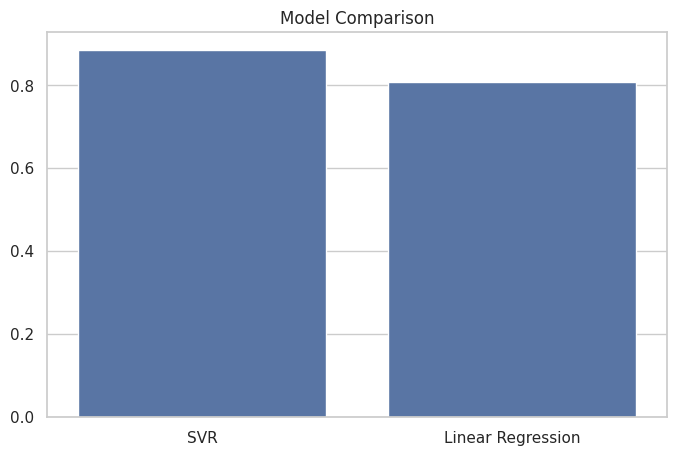

In [134]:
models = ['SVR', 'Linear Regression']
r2_scores = [r2_2, l_r2]

plt.figure(figsize=(8, 5))

ax = sns.barplot(x=models, y=r2_scores)

plt.title('Model Comparison')
plt.show()

SVR:
- R-squared (R2) score for Training Set: 0.8840312900330013


- Root Mean Squared Error (RMSE) for Training Set: 4616.27059569059


- Mean Squared Error (MSE) for Training Set: 21309954.21263756


Linear Regression:
- R-squared (R2) score for Training Set: 0.8069099329048421

- Root Mean Squared Error (RMSE) for Training Set: 5956.632571843689

- Mean Squared Error (MSE) for Training Set: 35481471.59594916

The SVR is clearly having a better results because it's better in delling with outliers but the linear regression is sensitive to outliers because it only draws a straight line while SVR can draw multiple shapes of the line until data is in the right fit (by changing the hyperparameters)